# What goes wrong when you supply your own filter curves?

> ⚠️ **Experimental.** A research demonstration using experimental APIs that may change between releases.

Every survey tengri does not already know about arrives as a directory of
transmission curves, in whatever format and whatever wavelength unit the
instrument team wrote them in. Three registration routes take them, and all
three resolve through `load_filter`, so a curve you supply works anywhere a
built-in one does and can shadow it by name.

The problem is that one of the ways this goes wrong does not raise. Tengri
wavelengths are Angstrom throughout, and a curve tabulated in nanometers is
still a perfectly valid array of numbers — it simply describes the extreme
ultraviolet, where the interstellar medium is opaque and no bandpass exists.
Nothing about it is malformed, so nothing complains. The filters land where
the model has no flux, the fit converges, and the error bars look ordinary.

7DT is the worked example: 3 broad (`g`, `r`, `i`) plus 20 medium bands on a
25 nm grid, `m400`–`m875`. Those 23 ship with tengri as `7dt_*` and need no
registration, so the last two sections use them directly. Everything before
that is what to do when your filters are not already built in.

In [1]:
from _setup import quiet

quiet()

import tempfile
import warnings
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    builders,
    generate_mock,
    plot,
)
from tengri.observation.filters import load_filter
from tengri.observation.filters.custom import (
    register_filter,
    register_filter_from_file,
    unregister_filter,
)

plot.setup_style()

C_DATA, C_MODEL = "#c3372a", "#3a76d9"
WORK = Path(tempfile.mkdtemp(prefix="tengri_filters_"))

## What a delivered curve looks like

Curves rarely arrive as two whitespace-separated columns in Angstrom. The 7DT
delivery is one CSV per band with a `lam,trans` header, wavelength in
**nanometers** on a uniform 0.1 nm grid, zero-padded out to 300–1000 nm. The
cell below fabricates one in exactly that shape.

In [2]:
lam_nm = np.arange(300.0, 1000.1, 0.1)
trans = 0.34 * np.exp(-0.5 * ((lam_nm - 401.0) / 10.3) ** 2)

delivered = WORK / "m400.csv"
delivered.write_text(
    "lam,trans\n" + "\n".join(f"{w:.5f},{t:.5f}" for w, t in zip(lam_nm, trans, strict=True))
)
print(delivered.read_text()[:64].replace("\n", " | "))

lam,trans | 300.00000,0.00000 | 300.10000,0.00000 | 300.20000,0.00000 | 


Tengri reads this as it stands. Columns may be comma- or whitespace-separated,
with or without a header row, and `#` comment lines are ignored. The file
extension does not matter.

## Route 1: in-memory, from arrays

`register_filter` puts a curve in the process-local registry under a name.
From that point it resolves anywhere a built-in does.

In [3]:
register_filter("demo_from_arrays", lam_nm, trans, wave_unit="nm", overwrite=True)
fc = load_filter("demo_from_arrays")
print(f"{fc.name}: {fc.wave.min():.0f}-{fc.wave.max():.0f} AA, peak T = {fc.trans.max():.3f}")

demo_from_arrays: 3000-10000 AA, peak T = 0.340


## Route 2: in-memory, from a file

The same registry, reading the file directly. Declaring `wave_unit` is what
makes this safe, for the reason the next section works through.

In [4]:
register_filter_from_file("demo_from_file", delivered, wave_unit="nm", overwrite=True)
print(np.allclose(load_filter("demo_from_file").wave, load_filter("demo_from_arrays").wave))

True


## Route 3: `$TENGRI_FILTER_DIR`

A `:`-separated directory list, searched by file stem, with no code call at
all. This is the route that survives being handed to someone else: a config
naming `m400` resolves on any machine that has the directory, where the other
two live and die with the process.

It also has nowhere to record a unit, since a bare directory of files carries
no metadata, so **files dropped here must already be in Angstrom.**

In [5]:
import os

filter_dir = WORK / "curves"
filter_dir.mkdir(exist_ok=True)
np.savetxt(filter_dir / "m400_dir.dat", np.column_stack([lam_nm * 10.0, trans]))
os.environ["TENGRI_FILTER_DIR"] = str(filter_dir)

print(f"resolved by stem: {load_filter('m400_dir').wave.max():.0f} AA")

resolved by stem: 10000 AA


## The mistake that does not raise

If you register without declaring the unit, tengri checks whether the numbers
could plausibly be Angstrom and warns when they could not. No real bandpass
lies between 100 Å and 1340 Å, because the interstellar medium is opaque
there, so a curve sitting entirely inside that range is almost certainly in
nanometers.

In [6]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    register_filter("demo_unstated", lam_nm, trans, overwrite=True)

print(str(caught[0].message) if caught else "no warning")

Filter 'demo_unstated' custom filter spans 300-1000 Å, which lies entirely in the extreme-UV (100-1340 Å). The ISM is opaque there, so no photometric bandpass exists in that window -- these are most likely **nanometers**. If so, multiply by 10: 300-1000 nm -> 3000-10000 Å. tengri wavelengths are Angstrom throughout. Pass wave_unit='nm' to convert at the boundary instead of relying on this check.


The cost of missing it. The curve sits at 300–1000 Å, where the SED carries
essentially no flux, so the predicted photometry is not so much wrong as
meaningless — and every fit still converges, with error bars that look
entirely reasonable.

In [7]:
wrong = load_filter("demo_unstated")
right = load_filter("demo_from_arrays")
print(f"unstated : {wrong.wave.min():7.0f} - {wrong.wave.max():7.0f} AA")
print(f"nm stated: {right.wave.min():7.0f} - {right.wave.max():7.0f} AA")
print(f"ratio    : {float(right.wave.max() / wrong.wave.max()):.0f}x")

for name in ("demo_from_arrays", "demo_from_file", "demo_unstated"):
    unregister_filter(name)

unstated :     300 -    1000 AA
nm stated:    3000 -   10000 AA
ratio    : 10x


Treat that warning as a backstop, not a guarantee. It cannot catch microns at
all: an optical curve in microns lands at 0.5–0.7 Å, which is indistinguishable
from a real X-ray band. It also stays quiet on a nanometer set that runs past
1340 nm. **State the unit and you never depend on it.**

## The 23 bundled 7DT bands

These need none of the above. They ship with tengri and load by name like any
other filter. They are total system response, with detector QE and optics
folded in, which is what 7DT photometry is measured through.

In [8]:
BANDS_BROAD = ["7dt_g", "7dt_r", "7dt_i"]
BANDS_MEDIUM = [f"7dt_m{lam}" for lam in range(400, 900, 25)]
FILTERS = BANDS_MEDIUM + BANDS_BROAD

print(tengri.list_filters(survey="7dt")[:4])
print(f"\n{len(FILTERS)} bands")

[{'name': '7dt_g', 'kind': 'filter', 'survey': '7DT', 'instrument': '7DT', 'band': 'g', 'alias': '7dt_g', 'use': 'Photometry.from_names(["7dt_g"])'}, {'name': '7dt_i', 'kind': 'filter', 'survey': '7DT', 'instrument': '7DT', 'band': 'i', 'alias': '7dt_i', 'use': 'Photometry.from_names(["7dt_i"])'}, {'name': '7dt_m400', 'kind': 'filter', 'survey': '7DT', 'instrument': '7DT', 'band': 'm400', 'alias': '7dt_m400', 'use': 'Photometry.from_names(["7dt_m400"])'}, {'name': '7dt_m425', 'kind': 'filter', 'survey': '7DT', 'instrument': '7DT', 'band': 'm425', 'alias': '7dt_m425', 'use': 'Photometry.from_names(["7dt_m425"])'}]

23 bands


The peak transmission is not flat across the medium bands: 0.34 at `m400`,
rising to 0.66 near 500 nm, falling to 0.07 at `m875`. Twenty separate
filters do not share one smooth envelope by accident — that is the detector
QE showing through. It is harmless for AB photometry, since a constant scale
on $T$ cancels in the ratio of the two bandpass integrals and only the shape
survives. It would matter if these were used to predict absolute count rates.

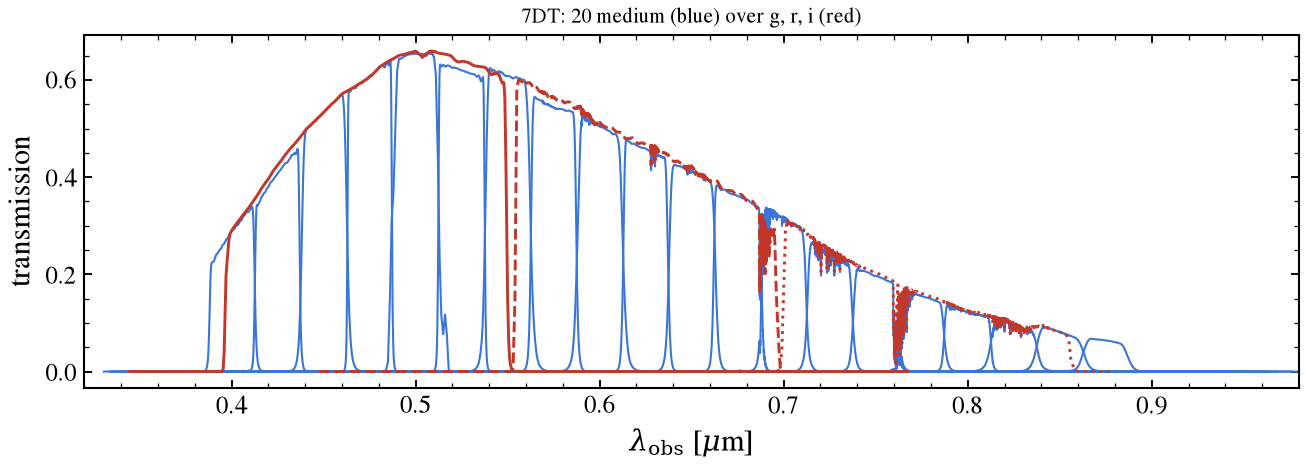

In [9]:
fig, ax = plt.subplots(figsize=(9.0, 3.4))
for name in BANDS_MEDIUM:
    fc = load_filter(name)
    ax.plot(np.asarray(fc.wave) / 1e4, np.asarray(fc.trans), lw=1.0, color=C_MODEL)
for name, ls in zip(BANDS_BROAD, ["-", "--", ":"], strict=True):
    fc = load_filter(name)
    ax.plot(np.asarray(fc.wave) / 1e4, np.asarray(fc.trans), lw=1.4, ls=ls, color=C_DATA)
ax.set(xlabel=r"$\lambda_{\rm obs}$ [$\mu$m]", ylabel="transmission", xlim=(0.32, 0.98))
ax.set_title("7DT: 20 medium (blue) over g, r, i (red)", fontsize=10)
fig.tight_layout()

## ADU and a zeropoint, taken to a fit

Instrument tables rarely arrive in $F_\nu$. Counts in ADU with a per-band AB
zeropoint are common, and they are one step away from a unit tengri ingests:

$$m_{\rm AB} = \mathrm{ZP}_b - 2.5\log_{10} f_{\rm ADU}, \qquad
  \sigma_m = 1.0857\,\sigma_f / f_{\rm ADU}.$$

Convert to AB magnitudes first, then pass `flux_unit="ab_mag"`. Tengri has no
ADU option, because a zeropoint is calibration specific to your data rather
than a unit it could know about.

The ADU below is synthesized from a known model, so the recovered answer can
be checked against something.

In [10]:
ZP = dict.fromkeys(FILTERS, 23.89)  # one per band in practice; near-identical here

ssp = tengri.load_ssp("fsps_prsc_miles_chabrier", download=True)
obs = Observation(photometry=Photometry.from_names(FILTERS))

sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh=builders.sfh.tsnorm(all_params=FREE),
    dust_attenuation=builders.dust.two_component(
        all_params=FIXED, law="calzetti", tau_diff=Uniform(0.0, 1.0)
    ),
    dust_emission=builders.dust.emission.modified_blackbody(all_params=FIXED),
    neb=builders.neb.none(),
    met={"logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(0.0062),  # a nearby galaxy
)
forward = ForwardModel.build(sed=sed_model)
print(f"free parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

free parameters (7): dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_skew, sfh_tsnorm_trunc, sfh_tsnorm_width_gyr


In [11]:
key_truth, key_mock, key_fit = jax.random.split(jax.random.PRNGKey(11), 3)
truth = sed_model.spec.sample(key_truth)
mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)

fnu = np.asarray(mock["flux_obs"])
sigma = np.asarray(mock["noise"])

# Push the model fluxes out into ADU so the cells below can bring them back the
# way you would handle a real table.
mag = -2.5 * np.log10(fnu) - 48.60
adu = 10.0 ** (-0.4 * (mag - np.array([ZP[b] for b in FILTERS])))
adu_err = adu * np.log(10.0) / 2.5 * (1.0857 * sigma / fnu)

print(f"ADU range: {adu.min():.1f} - {adu.max():.1f}")

ADU range: 660801.7 - 2074805.5


`ingest_catalog` takes explicit `flux_cols` and `err_cols`, so your column
names can be whatever the table already uses. Give it the redshift column
too: a redshift left unstated is not a safe default to accept.

In [12]:
from tengri.inference.catalog_ingest import ingest_catalog

mag_obs = np.array([ZP[b] for b in FILTERS]) - 2.5 * np.log10(adu)
mag_err = 1.0857 * adu_err / adu

table = {"redshift": np.array([0.0062])}
for j, band in enumerate(FILTERS):
    table[f"flux_{band}"] = np.array([mag_obs[j]])
    table[f"err_{band}"] = np.array([mag_err[j]])

arrays = ingest_catalog(
    table,
    photometry=obs.photometry,
    flux_unit="ab_mag",
    flux_cols=[f"flux_{b}" for b in FILTERS],
    err_cols=[f"err_{b}" for b in FILTERS],
    redshift_col="redshift",
)
print(f"round-trip max |dF/F|: {np.abs(arrays.flux[0] / fnu - 1.0).max():.2e}")

round-trip max |dF/F|: 1.17e-14


The round trip closes to machine precision, so the ADU-to-AB-to-$F_\nu$ chain
introduces nothing of its own.

On errors: check whether your uncertainties already include the zeropoint
term before adding `NoiseModel(calibration_floor=...)`. Many catalogs fold it
in, and setting both counts it twice.

A zeropoint error is also shared across every source measured in that band
rather than drawn independently per source. No per-fit floor represents that,
which is worth knowing if you later fit sources jointly or read a trend across
them, and does not matter when fitting one at a time.

In [13]:
map_result = forward.fit(arrays.flux[0], arrays.noise[0], method="map", key=key_fit, n_steps=300)

for pname in sed_model.spec.free_params:
    print(f"  {pname:24} fit {float(map_result.params[pname]):+8.3f}   truth {float(truth[pname]):+8.3f}")

    step 200: loss=15.4656
  MAP (ADAM) complete in 0.3s, 300 steps, loss=14.1370
  dust_tau_diff            fit   +0.304   truth   +0.188
  met_logzsol              fit   -0.242   truth   +0.092
  sfh_tsnorm_log_total_mass fit  +11.351   truth  +11.432
  sfh_tsnorm_peak_lbt_gyr  fit   +3.356   truth   +3.760
  sfh_tsnorm_skew          fit   +0.567   truth   +0.389
  sfh_tsnorm_trunc         fit   +3.690   truth   +6.061
  sfh_tsnorm_width_gyr     fit   +2.724   truth   +2.732


Mass and SFH width come back tightly; metallicity and dust do not. That is the
age-metallicity-dust degeneracy rather than a filter problem: 23 optical bands
with no UV and no infrared do not break it. A MAP fit also returns a single
point, so it cannot show you the correlation that explains the offset. Use
`method="mcmc_nuts"` when you want the posterior rather than a quick check.

## Scaling up

This fits one source. For many, `Fitter.fit_batch` shares the compilation
cache across them, so the first fit pays for the compile and the rest do not.
That makes the per-fit cost the number to measure before starting a long run:
time a few dozen of your own sources and multiply, rather than extrapolating
from the first fit, which is mostly compilation.

In [14]:
del os.environ["TENGRI_FILTER_DIR"]
unregister_filter("m400_dir")
print("done")

done
